# Evaluation of Simple Linear Regression: EDA, Model Building, Assumption Checking, and Interpretation

## Project Objective
This notebook evaluates a simple linear regression model to understand how **TV advertising spend** influences **Sales**.

## Business Question
How strongly does TV advertising predict sales, and what budget recommendation can be made from the model results?

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## Load Dataset

In [53]:
data_path = Path('marketing_and_sales_data_evaluate_lr.csv')
df = pd.read_csv(data_path)
print(f'Dataset loaded from: {data_path.resolve()}')
print(f'Shape before cleaning: {df.shape}')
df.head()

Dataset loaded from: C:\Users\hp\Desktop\3mtt dare task\week_4\marketing_and_sales_data_evaluate_lr.csv
Shape before cleaning: (4572, 4)


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


## Data Exploration

In [54]:
print('Columns:', list(df.columns))
print('\nData types:')
print(df.dtypes)
print('\nMissing values before cleaning:')
print(df.isna().sum())

Columns: ['TV', 'Radio', 'Social_Media', 'Sales']

Data types:
TV              float64
Radio           float64
Social_Media    float64
Sales           float64
dtype: object

Missing values before cleaning:
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64


In [55]:
# Project requirement: explicitly handle missing values in the Sales column
sales_missing_before = df['Sales'].isna().sum()
df = df.dropna(subset=['Sales']).copy()
print(f"Rows removed because Sales was missing: {sales_missing_before}")
print(f"Shape after dropping missing Sales values: {df.shape}")
print('Missing values after Sales cleanup:')
print(df.isna().sum())

Rows removed because Sales was missing: 6
Shape after dropping missing Sales values: (4566, 4)
Missing values after Sales cleanup:
TV              10
Radio            4
Social_Media     6
Sales            0
dtype: int64


In [56]:
# Keep only the columns needed for simple linear regression and remove any remaining missing predictor values
model_df = df[['TV', 'Sales']].dropna().copy()
print(f'Modeling dataset shape: {model_df.shape}')
model_df.describe().T

Modeling dataset shape: (4556, 2)


,count,mean,std,min,25%,50%,75%,max
TV,4556.0,54.068042,26.116949,10.000000,32.00000,53.000000,77.000000,100.000000
Sales,4556.0,192.432199,93.059960,31.199409,112.39766,188.963678,272.407947,364.079751


## Visual Exploration

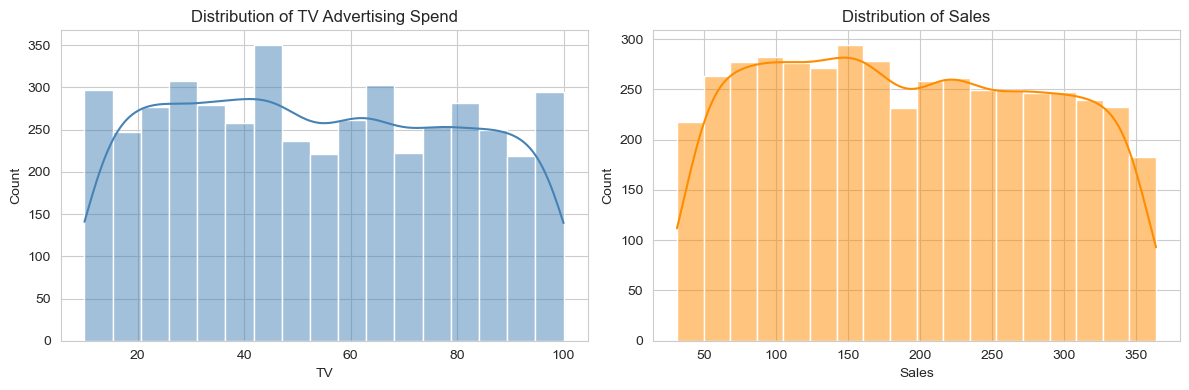

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(model_df['TV'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of TV Advertising Spend')
axes[0].set_xlabel('TV')

sns.histplot(model_df['Sales'], kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution of Sales')
axes[1].set_xlabel('Sales')

plt.tight_layout()
plt.show()

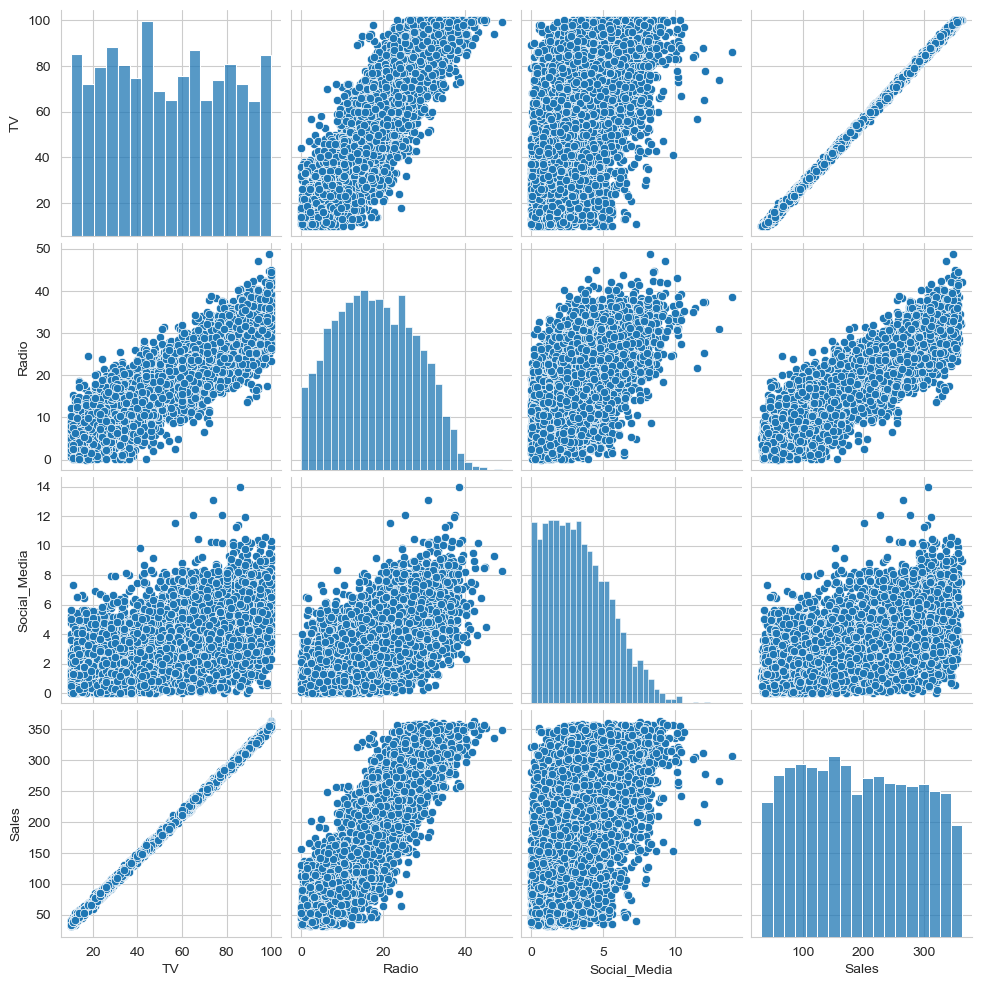

In [58]:
sns.pairplot(df[['TV', 'Radio', 'Social_Media', 'Sales']].dropna())
plt.show()

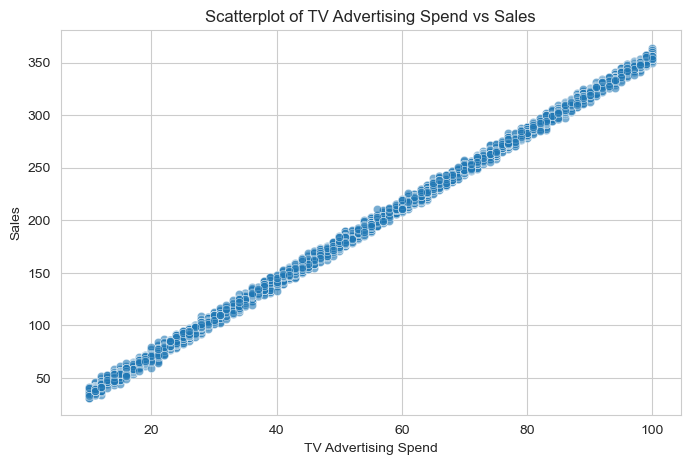

In [59]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=model_df, x='TV', y='Sales', alpha=0.6)
plt.title('Scatterplot of TV Advertising Spend vs Sales')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.show()

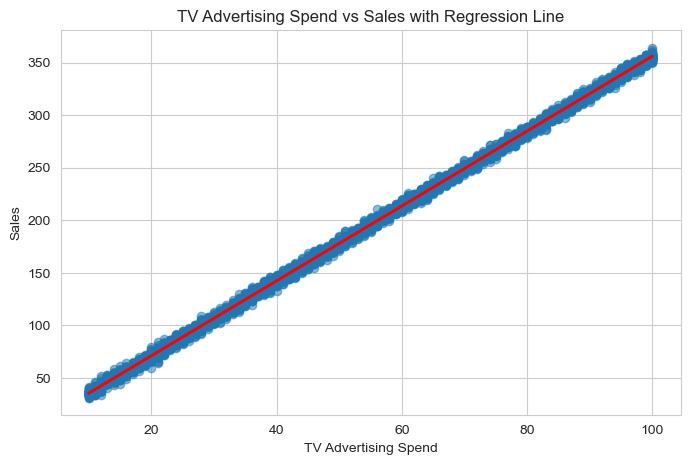

In [60]:
plt.figure(figsize=(8, 5))
sns.regplot(data=model_df, x='TV', y='Sales', scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('TV Advertising Spend vs Sales with Regression Line')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.show()

## Build the Simple Linear Regression Model

In [61]:
# OLS formula definition
ols_formula = 'Sales ~ TV'
print('OLS Formula:', ols_formula)

model = smf.ols(formula=ols_formula, data=model_df).fit()
print(model.summary())

OLS Formula: Sales ~ TV
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.527e+06
Date:                Sun, 21 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:23:16   Log-Likelihood:                -11393.
No. Observations:                4556   AIC:                         2.279e+04
Df Residuals:                    4554   BIC:                         2.280e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1263      0

In [62]:
intercept = model.params['Intercept']
slope = model.params['TV']
r_squared = model.rsquared
p_value_tv = model.pvalues['TV']

print(f'Linear Equation: Sales = {intercept:.4f} + {slope:.4f} * TV')
print(f'R-squared: {r_squared:.4f}')
print(f'P-value for TV coefficient: {p_value_tv:.6f}')

Linear Equation: Sales = -0.1263 + 3.5614 * TV
R-squared: 0.9990
P-value for TV coefficient: 0.000000


## Actual vs Predicted Values

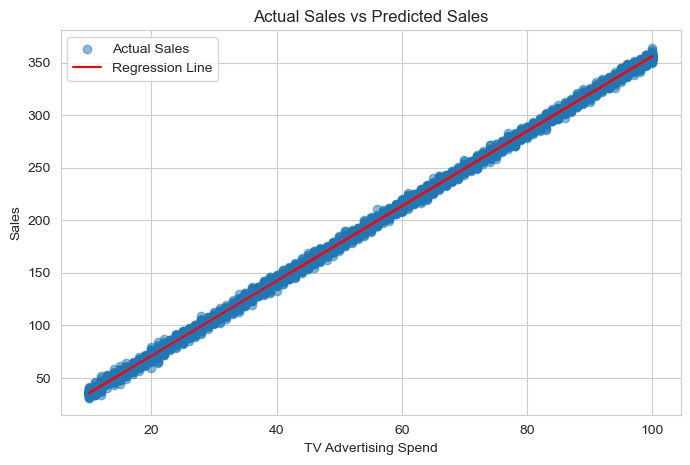

In [63]:
model_df['Predicted_Sales'] = model.predict(model_df)

plt.figure(figsize=(8, 5))
plt.scatter(model_df['TV'], model_df['Sales'], label='Actual Sales', alpha=0.5)
plt.plot(model_df['TV'], model_df['Predicted_Sales'], color='red', label='Regression Line')
plt.title('Actual Sales vs Predicted Sales')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.legend()
plt.show()

## Diagnostic Plots for Assumption Checking

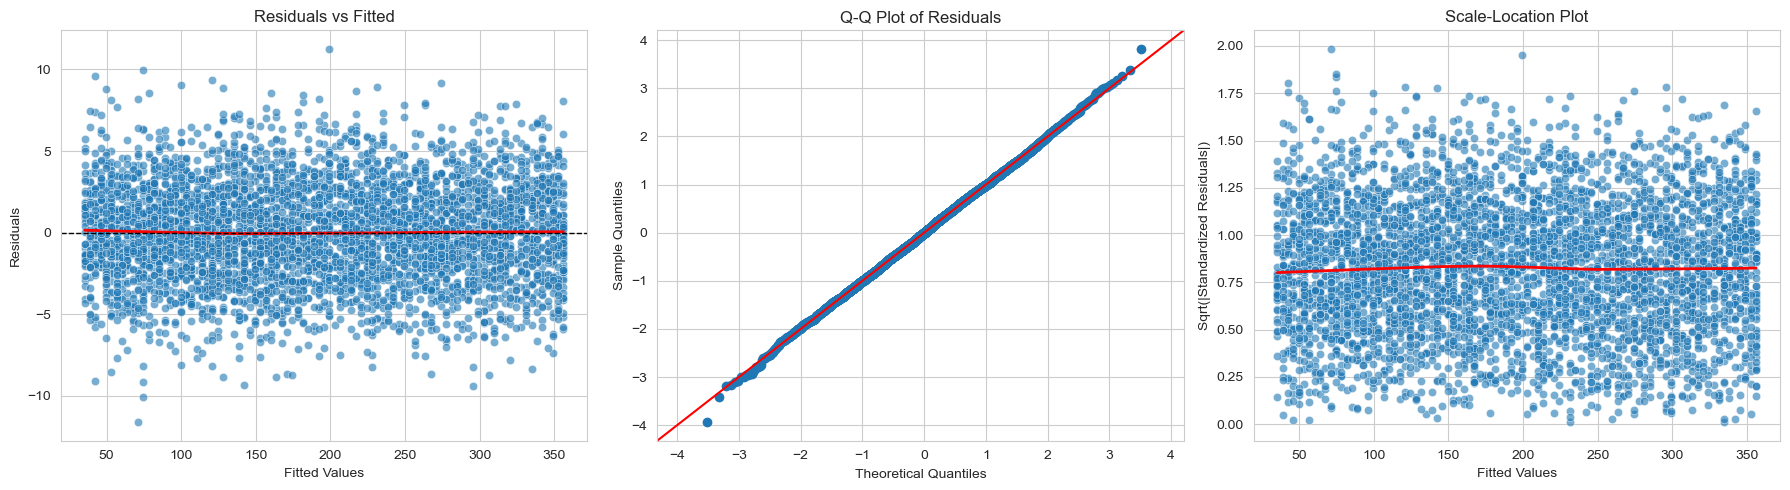

In [64]:
residuals = model.resid
fitted_values = model.fittedvalues
standardized_residuals = residuals / residuals.std()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Linearity
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0], alpha=0.6)
sns.regplot(x=fitted_values, y=residuals, scatter=False, lowess=True,
            line_kws={'color': 'red', 'lw': 2}, ax=axes[0])
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# Normality
sm.qqplot(residuals, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

# Homoscedasticity
sns.scatterplot(x=fitted_values, y=np.sqrt(np.abs(standardized_residuals)), ax=axes[2], alpha=0.6)
sns.regplot(x=fitted_values, y=np.sqrt(np.abs(standardized_residuals)), scatter=False, lowess=True,
            line_kws={'color': 'red', 'lw': 2}, ax=axes[2])
axes[2].set_title('Scale-Location Plot')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Sqrt(|Standardized Residuals|)')

plt.tight_layout()
plt.show()

## Interpretation in Business Context

In [65]:
print('R-squared interpretation:')
print(
    f"The model explains {r_squared * 100:.2f}% of the variation in Sales using TV advertising spend alone. "
    f"This suggests TV is a very strong predictor of Sales in this dataset."
)

print('\nCoefficient interpretation:')
print(
    f"The TV coefficient is {slope:.4f}. This means that, on average, a 1-unit increase in TV advertising spend "
    f"is associated with an estimated {slope:.2f}-unit increase in Sales."
)

print('\nP-value interpretation:')
print(
    f"The p-value for TV is {p_value_tv:.6f}. Because this is far below 0.05, the relationship between TV advertising "
    f"and Sales is statistically significant."
)

R-squared interpretation:
The model explains 99.90% of the variation in Sales using TV advertising spend alone. This suggests TV is a very strong predictor of Sales in this dataset.

Coefficient interpretation:
The TV coefficient is 3.5614. This means that, on average, a 1-unit increase in TV advertising spend is associated with an estimated 3.56-unit increase in Sales.

P-value interpretation:
The p-value for TV is 0.000000. Because this is far below 0.05, the relationship between TV advertising and Sales is statistically significant.


## ROI-Based Recommendation and Conclusion

In [66]:
print('Recommendation:')
print(
    'Based on the model, the business should allocate a larger share of the marketing budget to TV advertising. '
    'TV shows a strong positive and statistically significant relationship with Sales, and the model explains most of '
    'the variation in Sales using TV alone.'
)

print('\nImportant caution:')
print(
    'This recommendation is a sales-response recommendation rather than a full profit-based ROI calculation. '
    'A true ROI decision should also consider channel costs, profit margin, and compare TV against Radio and Social_Media '
    'in a multiple regression model.'
)

print('\nFinal conclusion:')
print(
    f"Simple linear regression indicates that TV advertising is a major driver of Sales. The estimated equation is: "
    f"Sales = {intercept:.4f} + {slope:.4f} * TV."
)

Recommendation:
Based on the model, the business should allocate a larger share of the marketing budget to TV advertising. TV shows a strong positive and statistically significant relationship with Sales, and the model explains most of the variation in Sales using TV alone.

Important caution:
This recommendation is a sales-response recommendation rather than a full profit-based ROI calculation. A true ROI decision should also consider channel costs, profit margin, and compare TV against Radio and Social_Media in a multiple regression model.

Final conclusion:
Simple linear regression indicates that TV advertising is a major driver of Sales. The estimated equation is: Sales = -0.1263 + 3.5614 * TV.
